<IPython.core.display.Javascript object>


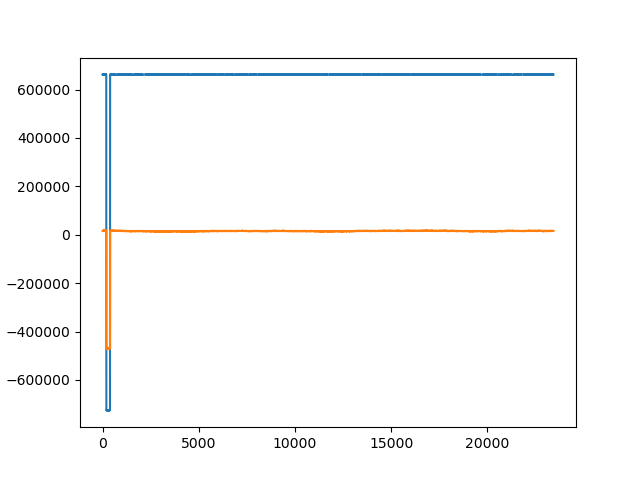

In [72]:
%matplotlib notebook

# Adapted from https://github.com/CornellCosmoLab/FTScode/blob/master/jul28_data_analysis.py

import matplotlib.pyplot as plt
import numpy as np

RFSOC_SAMP_RATE = 512E6 / 2**20 # 488.28125 Hz

folder = "/home/rfsoc/Desktop/"
timestream = np.load(folder + "fts_data_aug4_3.npy")

detector_idx = 3
i = timestream[:,16+detector_idx*2]
q = timestream[:,17+detector_idx*2]

plt.figure()
plt.plot(i)
plt.plot(q)
plt.show()

<IPython.core.display.Javascript object>


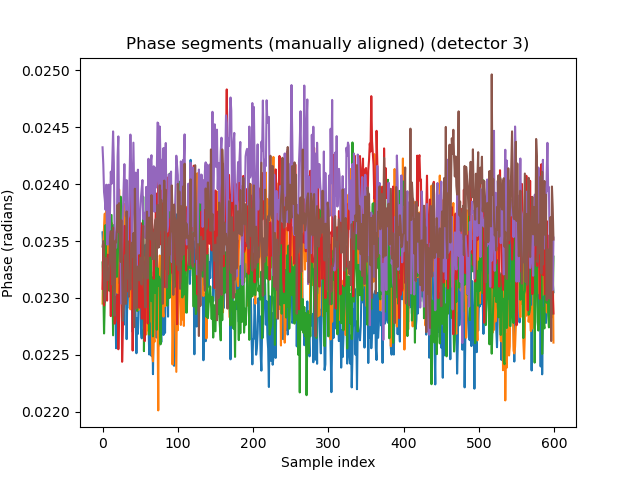

In [73]:
bandwidth = 600
half_bandwidth = round(bandwidth / 2)
phase = np.arctan2(q, i)

phase_sections = []
band_centers = [2120, 5766, 9976, 13629, 17846, 21486] # For 6 passes at 20 mm/s
for idx in range(len(band_centers)):
    if idx % 2 == 0:
        phase_sections.append(phase[band_centers[idx]-half_bandwidth:band_centers[idx]+half_bandwidth])
    else:
        phase_sections.append(np.flip(phase[band_centers[idx]-half_bandwidth:band_centers[idx]+half_bandwidth]))
plt.figure()
for idx in range(len(phase_sections)):
    plt.plot(phase_sections[idx], label=str(idx))
# plt.legend()
plt.title("Phase segments (manually aligned) (detector "+str(detector_idx)+")")
plt.xlabel("Sample index")
plt.ylabel("Phase (radians)")
plt.show()

<IPython.core.display.Javascript object>


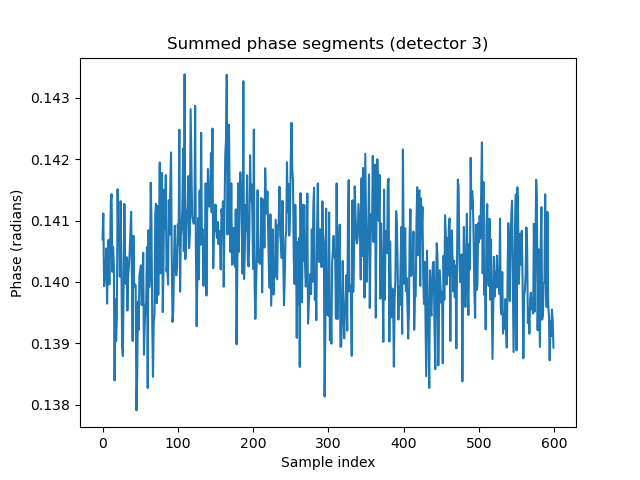

In [74]:
sections_sum = np.sum(phase_sections, axis=0)
plt.figure()
plt.plot(sections_sum)
plt.title("Summed phase segments (detector "+str(detector_idx)+")")
plt.xlabel("Sample index")
plt.ylabel("Phase (radians)")
plt.show()

In [75]:
# phase_segment = phase[1850:3200]
phase_segment = sections_sum
x = range(len(phase_segment))
fitvals = np.polyfit(x, phase_segment, deg=2)
fit = fitvals[0] * x * x + fitvals[1] * x + fitvals[2]

autocorrelation = phase_segment - fit
ft = np.fft.fft(autocorrelation)

# plt.figure()
# plt.title("Phase signal+autocorrelation, fit (detector "+str(detector_idx)+")")
# plt.plot(x, phase_segment)
# plt.plot(x, fit)
# plt.plot(x, autocorrelation)
# plt.show()

In [76]:
elec_freq = np.fft.fftfreq(len(ft), d=1.0/RFSOC_SAMP_RATE)
# plt.figure()
# plt.title("Electrical frequency (Hz) (detector "+str(detector_idx)+")")
# plt.plot(elec_freq, np.abs(ft)[:len(elec_freq)])
# plt.show()

In [77]:
wave_num = elec_freq / 2.0 # mirror speed is 2 cm/s
# plt.figure()
# plt.title("Wave number (1/cm) (detector "+str(detector_idx)+")")
# plt.plot(wave_num, np.abs(ft)[:len(elec_freq)])
# plt.show()

<IPython.core.display.Javascript object>


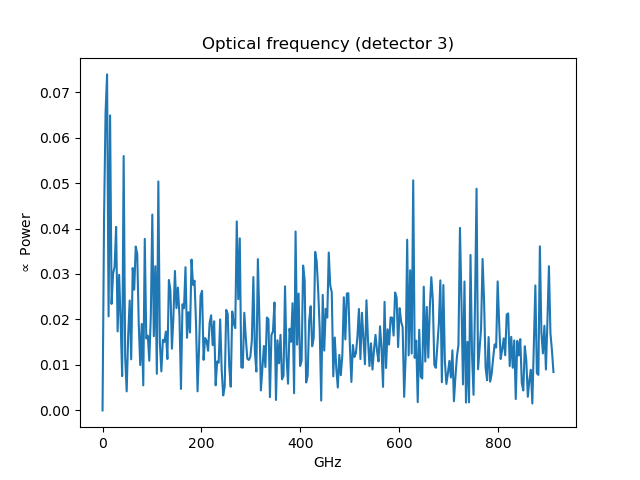

In [78]:
opt_freq = elec_freq * 3E8 / (0.02 * 1E9 * 4)
# opt_freq = elec_freq / 2
plt.figure()
plt.title("Optical frequency (detector "+str(detector_idx)+")")
plt.plot(opt_freq[:len(opt_freq) // 2], np.abs(ft)[:len(elec_freq) // 2])
plt.xlabel("GHz")
plt.ylabel("$\propto$ Power")
plt.show()